In [1]:
#basic
import os
import pandas as pd
import numpy as np

#visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#preparation
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from feature_engine.outliers import Winsorizer

#models
from sklearn.ensemble import RandomForestClassifier

#metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

#pytorch
import torch
import torch.nn as nn



In [2]:
folder_path = "covtype.data"

col_names = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Hillshade_9am", "Hillshade_Noon",
    "Hillshade_3pm", "Horizontal_Distance_To_Fire_Points",
    *[f"Wilderness_Area_{i}" for i in range(1, 5)],
    *[f"Soil_Type_{i}" for i in range(1, 41)],
    "Cover_Type"
]

rows = []
for filename in os.listdir(folder_path):
    name = os.path.splitext(filename)[0]
    values = name.split(",")
    if len(values) == len(col_names):
        rows.append(values)

df = pd.DataFrame(rows, columns=col_names)

pd.set_option('display.max_columns', None)

## WORKFLOW:
    1. Load data and quick overview (along with fixing dtypes, droppping duplicates, ...)
    2. Split data (test/train/val)
    3. EDA (visualisations, checking distributions, outliers, skewness on train set)
    4. Baseline model (Random Forests)
    5. Pipeline for MLP

# Choosen models:
    1. Random Forests(baseline)
    2. MLP

    Data preparation for RF:
        -Missing values: Random Forest can handle some missing values, but it’s better to impute: median for numeric, mode for binary.
        -Scaling/Normalization: Not needed.
        -Categorical features: If there were categories, you could use label encoding or one-hot, but Covertype usually doesn’t require it.
        -Outliers: Trees handle them well; no need to remove.
        -Target variable: Direct multi-class classification is fine.


    Data preparation for MLP:
        -Scaling / Normalization: Required.
        -Missing values:MLP cannot handle NaNs. Impute median for numeric and 0/1 for binary.
        -Categorical/binary features: Binary indicators can remain 0/1.Any categorical feature with >2 classes should be one-hot encoded.
        -Outliers: Should be removed or capped; they can destabilize gradients.
        -Target encoding: Use one-hot encoding for multi-class softmax output.
            

## 1. Data Overview

In [3]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,1863,37,17,120,18,90,217,202,115,769,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
1,1874,18,14,0,0,90,208,209,135,793,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
2,1879,28,19,30,12,95,209,196,117,778,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
3,1888,33,22,150,46,108,209,185,103,735,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
4,1889,28,22,150,23,120,205,185,108,759,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6


In [4]:
print("Shape of dataset: ", df.shape)


Shape of dataset:  (91448, 55)


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91448 entries, 0 to 91447
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Elevation                           91448 non-null  object
 1   Aspect                              91448 non-null  object
 2   Slope                               91448 non-null  object
 3   Horizontal_Distance_To_Hydrology    91448 non-null  object
 4   Vertical_Distance_To_Hydrology      91448 non-null  object
 5   Horizontal_Distance_To_Roadways     91448 non-null  object
 6   Hillshade_9am                       91448 non-null  object
 7   Hillshade_Noon                      91448 non-null  object
 8   Hillshade_3pm                       91448 non-null  object
 9   Horizontal_Distance_To_Fire_Points  91448 non-null  object
 10  Wilderness_Area_1                   91448 non-null  object
 11  Wilderness_Area_2                   91448 non-null  ob

None

In [6]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448,91448
unique,1665,361,60,435,440,5784,177,143,247,5827,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,7
top,2972,45,10,30,0,900,226,231,138,618,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
freq,725,1719,6832,5584,7459,111,2433,2672,1580,89,79925,90949,85099,86773,91093,90825,90486,90605,91283,90798,91343,91332,91438,89306,91042,71290,90972,91279,91448,89531,90836,89636,90813,86749,91432,91103,86494,89686,91447,91394,91433,91439,57392,82275,91116,90758,90832,91426,91346,91438,91414,90645,90585,90712,59305


In [7]:
df.nunique()

Elevation                             1665
Aspect                                 361
Slope                                   60
Horizontal_Distance_To_Hydrology       435
Vertical_Distance_To_Hydrology         440
Horizontal_Distance_To_Roadways       5784
Hillshade_9am                          177
Hillshade_Noon                         143
Hillshade_3pm                          247
Horizontal_Distance_To_Fire_Points    5827
Wilderness_Area_1                        2
Wilderness_Area_2                        2
Wilderness_Area_3                        2
Wilderness_Area_4                        2
Soil_Type_1                              2
Soil_Type_2                              2
Soil_Type_3                              2
Soil_Type_4                              2
Soil_Type_5                              2
Soil_Type_6                              2
Soil_Type_7                              2
Soil_Type_8                              2
Soil_Type_9                              2
Soil_Type_1

In [8]:
missing_vals = df.isna().sum()
missing_vals

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area_1                     0
Wilderness_Area_2                     0
Wilderness_Area_3                     0
Wilderness_Area_4                     0
Soil_Type_1                           0
Soil_Type_2                           0
Soil_Type_3                           0
Soil_Type_4                           0
Soil_Type_5                           0
Soil_Type_6                           0
Soil_Type_7                           0
Soil_Type_8                           0
Soil_Type_9                           0
Soil_Type_10                          0
Soil_Type_11                          0


In [9]:
#fix data types
df = df.apply(pd.to_numeric)

#drop duplicates if any
duplicates = df[df.duplicated()]
df = df.drop_duplicates() if len(duplicates) > 0 else df

In [10]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,1863,37,17,120,18,90,217,202,115,769,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
1,1874,18,14,0,0,90,208,209,135,793,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
2,1879,28,19,30,12,95,209,196,117,778,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
3,1888,33,22,150,46,108,209,185,103,735,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
4,1889,28,22,150,23,120,205,185,108,759,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6


## 2. Test/Train/Val split

In [11]:
#Separate target feature
X = df.drop(columns='Cover_Type')
y = df['Cover_Type']

#Split data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=40,
    stratify=y_train_val
)

#Split: 70% train, 15% test and 15% val

In [12]:
y_train_val

16714    2
80481    2
57113    2
38094    2
47310    2
        ..
19620    2
88377    1
31265    2
53602    2
75685    2
Name: Cover_Type, Length: 77730, dtype: int64

In [13]:
def class_dist(name, labels):
    dist = pd.Series(labels).value_counts().sort_index()
    print(f"{name}: {dist.to_dict()}")

class_dist("Full  ", y)
class_dist("Train ", y_train)
class_dist("Val   ", y_val)
class_dist("Test  ", y_test)


Full  : {1: 20943, 2: 59305, 3: 2160, 4: 2160, 5: 2560, 6: 2160, 7: 2160}
Train : {1: 14668, 2: 41536, 3: 1513, 4: 1513, 5: 1793, 6: 1513, 7: 1513}
Val   : {1: 3133, 2: 8873, 3: 323, 4: 323, 5: 383, 6: 323, 7: 323}
Test  : {1: 3142, 2: 8896, 3: 324, 4: 324, 5: 384, 6: 324, 7: 324}


## 3. EDA

- We will do eda on X_train_val and y_train_val as its 85% of all data and we wont leak any data this way

In [14]:
#Data for eda
train_val_df = X_train_val.copy()
train_val_df['Cover_Type'] = y_train_val.values

C:\Users\MSI\AppData\Local\Temp\ipykernel_24392\199953451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_val, palette='tab10')


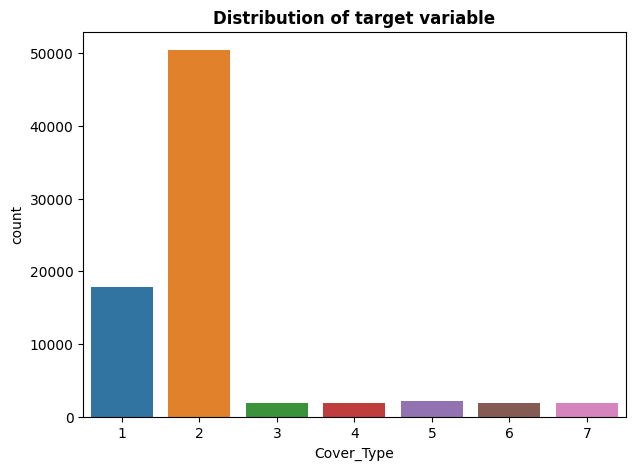

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(x=y_train_val, palette='tab10')
plt.title('Distribution of target variable', fontweight='bold')
plt.show()

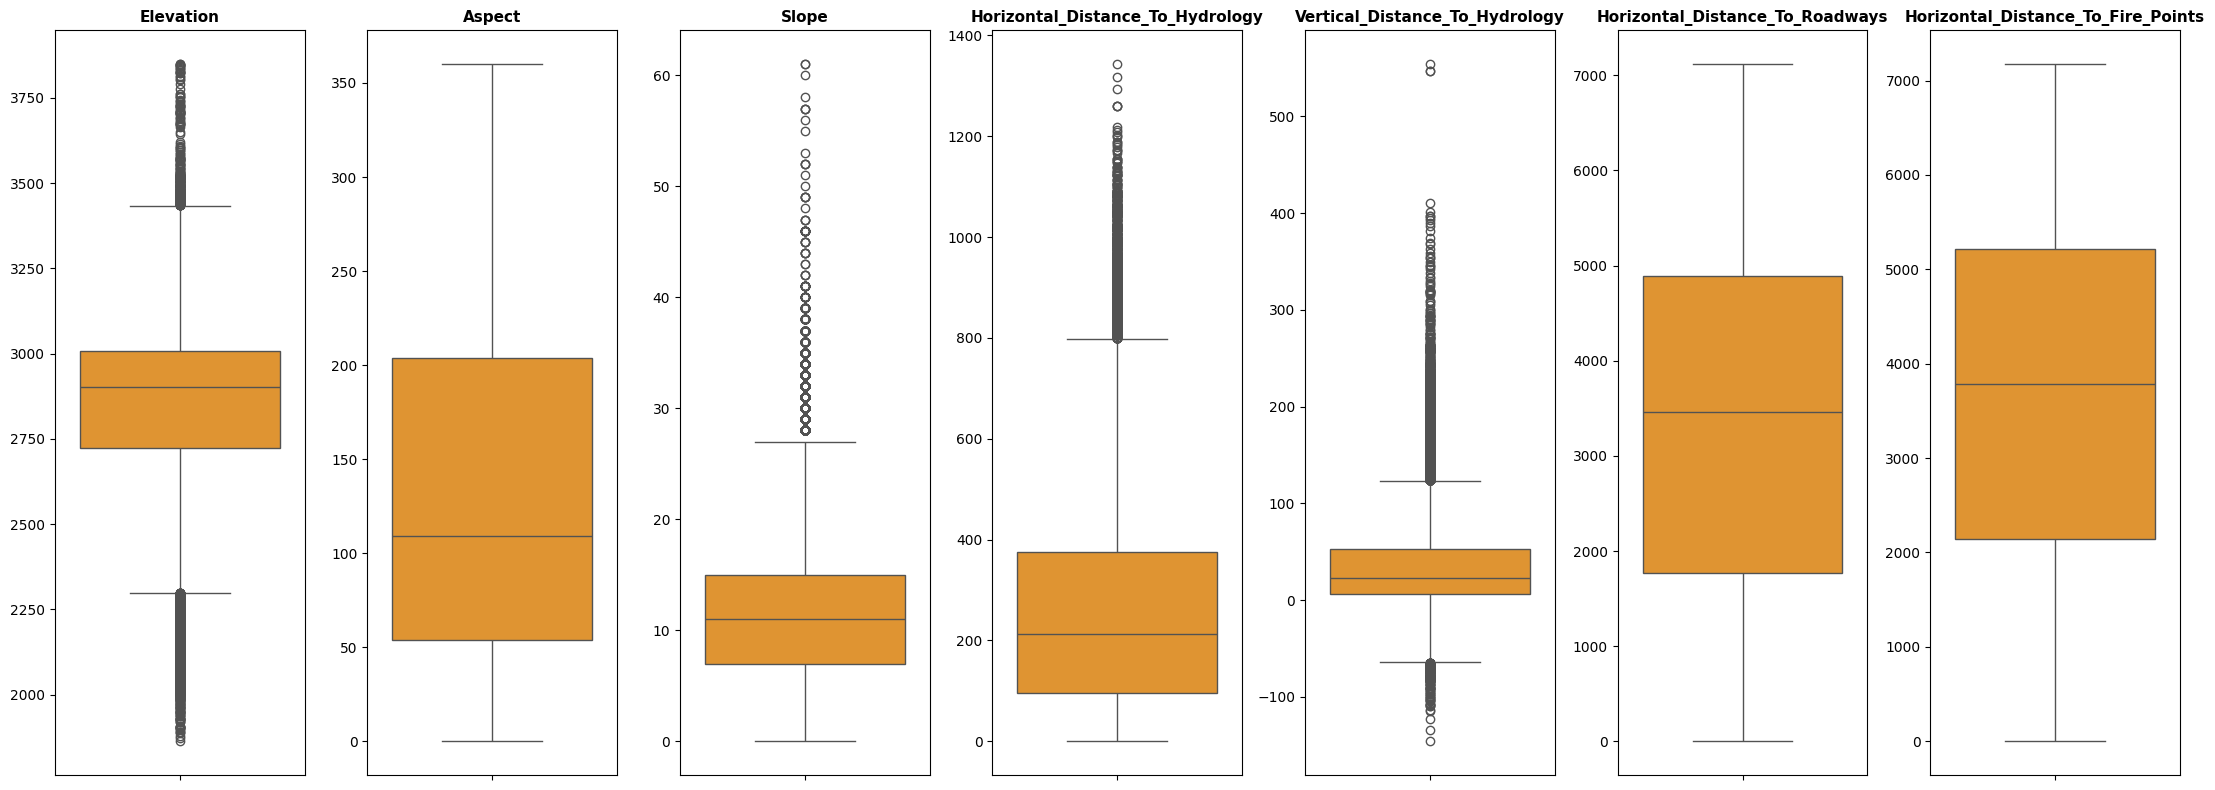

In [16]:
g_cols = ['Elevation','Aspect','Slope','Horizontal_Distance_To_Hydrology','Vertical_Distance_To_Hydrology','Horizontal_Distance_To_Roadways','Horizontal_Distance_To_Fire_Points']

fig, axes = plt.subplots(1, 7, figsize=(22, 8))
for i, col in enumerate(g_cols):
    sns.boxplot(data=train_val_df, y=col, ax=axes[i], color="#FC9815")
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel("")
plt.tight_layout()
plt.show()

In [17]:
#Check for outliers
Q1 = train_val_df[g_cols].quantile(0.25)
Q3 = train_val_df[g_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((train_val_df[g_cols] < Q1 - 1.5*IQR) | (train_val_df[g_cols] > Q3 + 1.5*IQR)).sum()
print(outliers)

Elevation                             2573
Aspect                                   0
Slope                                 2390
Horizontal_Distance_To_Hydrology      1543
Vertical_Distance_To_Hydrology        4072
Horizontal_Distance_To_Roadways          0
Horizontal_Distance_To_Fire_Points       0
dtype: int64


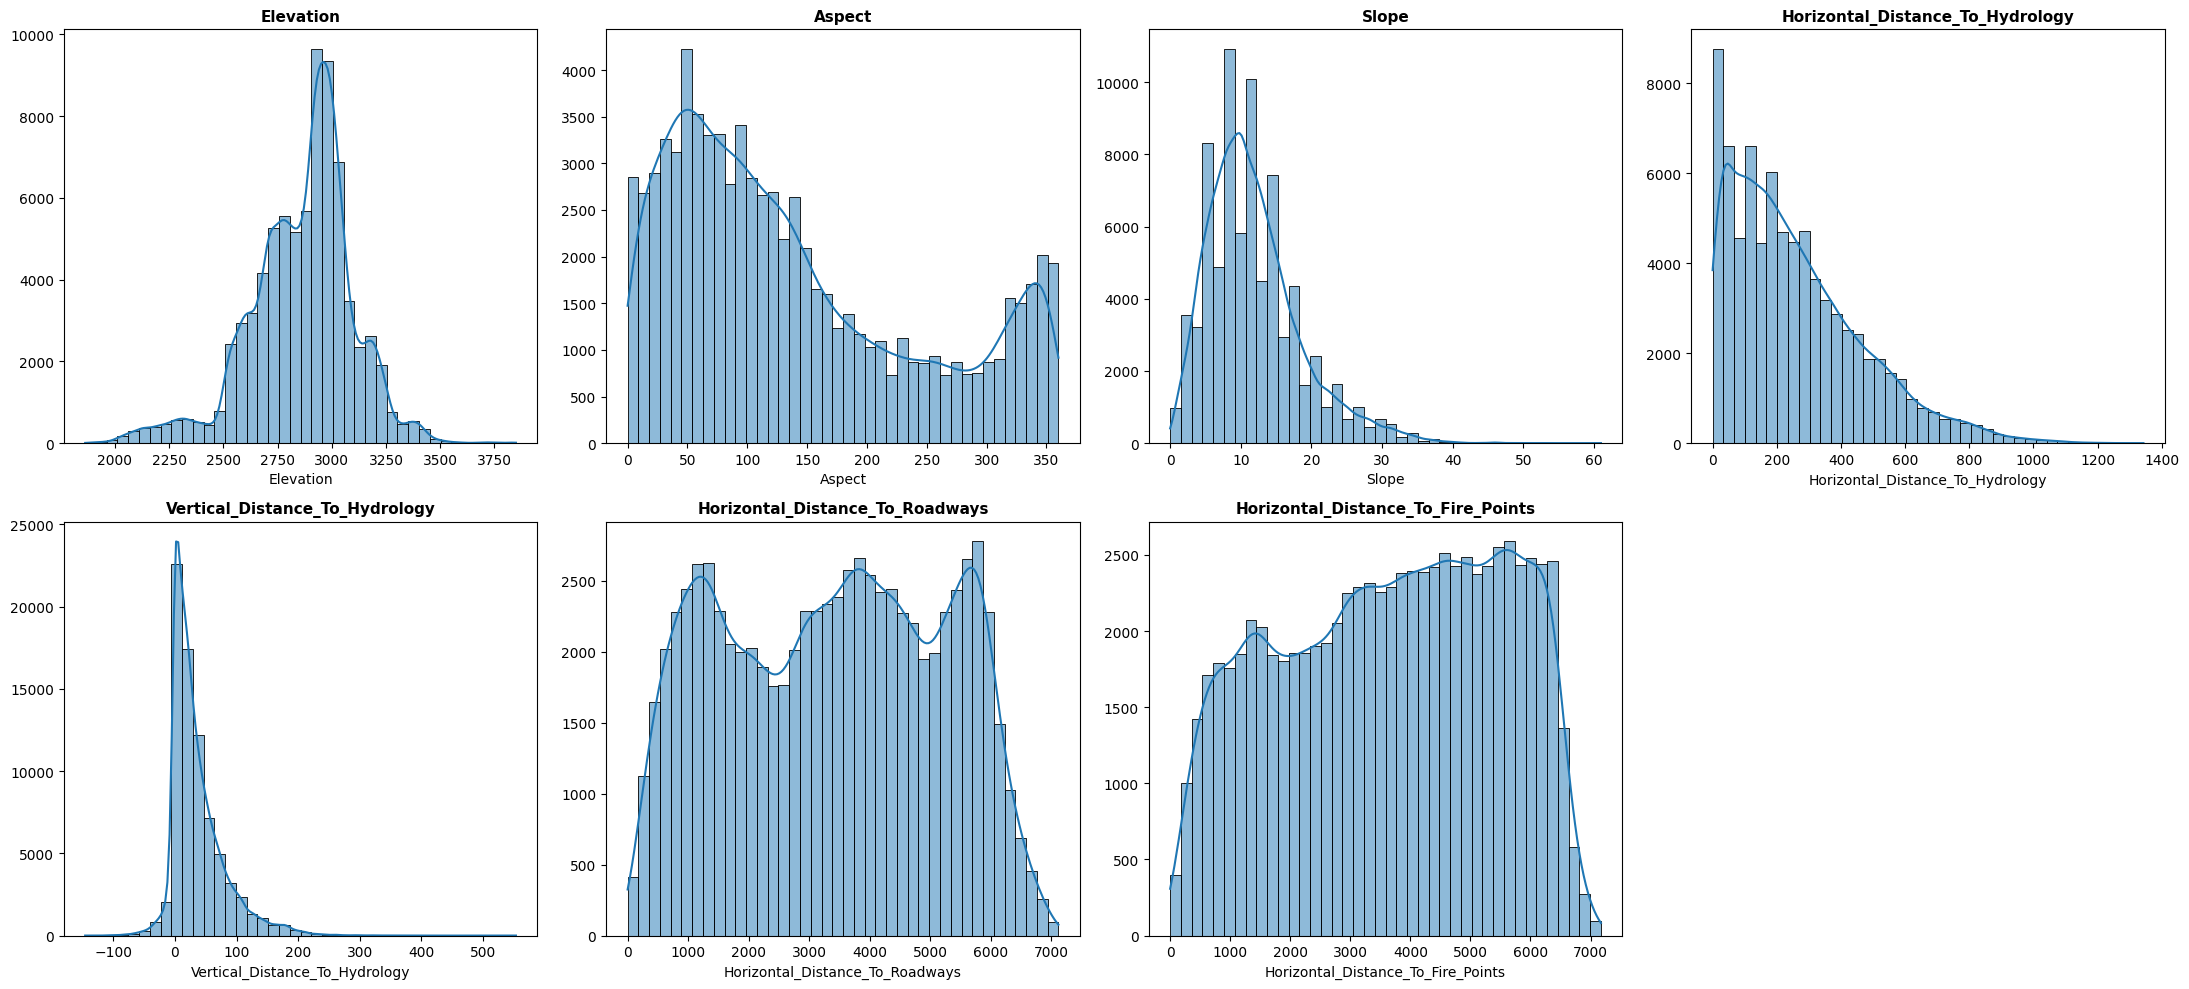

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(g_cols):
    sns.histplot(data=train_val_df[col], ax=axes[i], bins=40, kde=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel("")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
#Skewness of cols
print(train_val_df[g_cols].skew().sort_values(ascending=False))

Vertical_Distance_To_Hydrology        1.758903
Slope                                 1.095727
Horizontal_Distance_To_Hydrology      1.033811
Aspect                                0.721020
Horizontal_Distance_To_Roadways      -0.030296
Horizontal_Distance_To_Fire_Points   -0.158733
Elevation                            -0.610551
dtype: float64


C:\Users\MSI\AppData\Local\Temp\ipykernel_24392\3319623422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_val_df, x="Cover_Type", y="Elevation", palette='tab10')


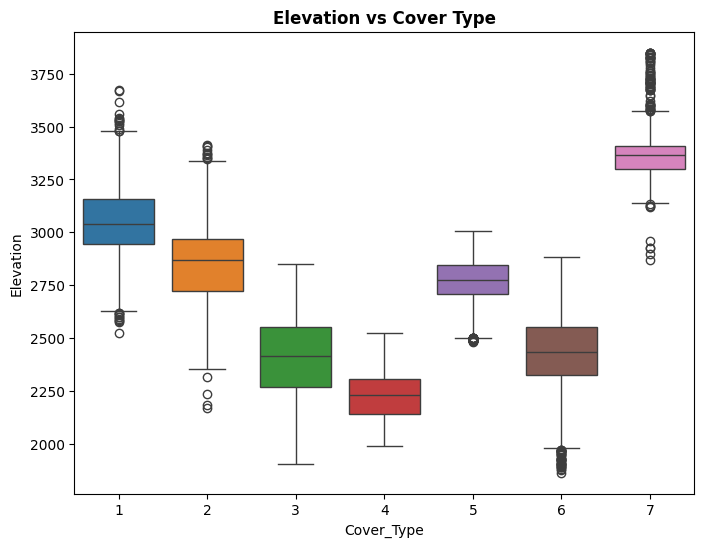

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(data=train_val_df, x="Cover_Type", y="Elevation", palette='tab10')
plt.title('Elevation vs Cover Type', fontweight='bold')
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_24392\1990324331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_val_df, x='Cover_Type', y='Horizontal_Distance_To_Hydrology', palette='tab10', ax=ax[0])
C:\Users\MSI\AppData\Local\Temp\ipykernel_24392\1990324331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_val_df, x='Cover_Type', y='Vertical_Distance_To_Hydrology', palette='tab10', ax=ax[1])


Text(0, 0.5, 'Distance')

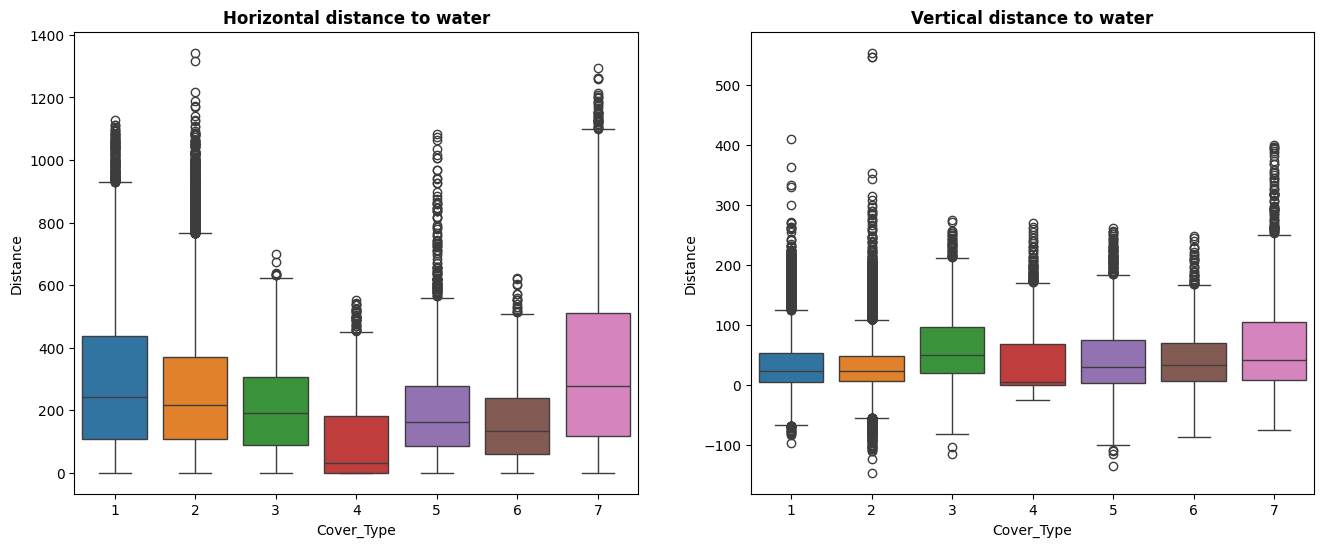

In [21]:
fig, ax = plt.subplots(1,2,figsize=(16,6))
sns.boxplot(data=train_val_df, x='Cover_Type', y='Horizontal_Distance_To_Hydrology', palette='tab10', ax=ax[0])
ax[0].set_title('Horizontal distance to water', fontweight='bold')
ax[0].set_ylabel('Distance')

sns.boxplot(data=train_val_df, x='Cover_Type', y='Vertical_Distance_To_Hydrology', palette='tab10', ax=ax[1])
ax[1].set_title('Vertical distance to water', fontweight='bold')
ax[1].set_ylabel('Distance')

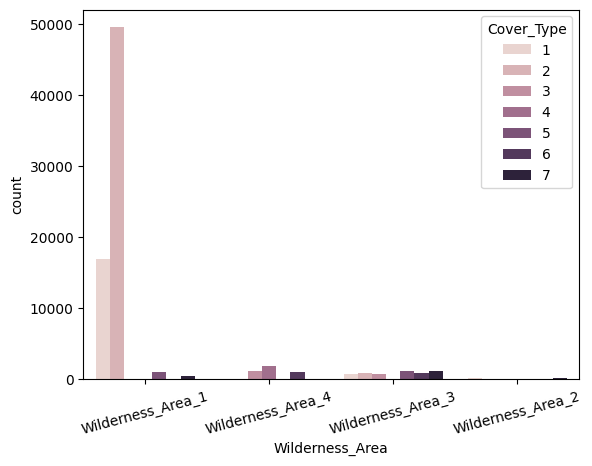

In [22]:
wilderness_cols = ['Wilderness_Area_1', 'Wilderness_Area_2', 
                   'Wilderness_Area_3', 'Wilderness_Area_4']

temp_df = train_val_df.copy()
temp_df['Wilderness_Area'] = temp_df[wilderness_cols].idxmax(axis=1)

sns.countplot(data=temp_df, x='Wilderness_Area', hue='Cover_Type')
plt.xticks(rotation=15)
plt.show()

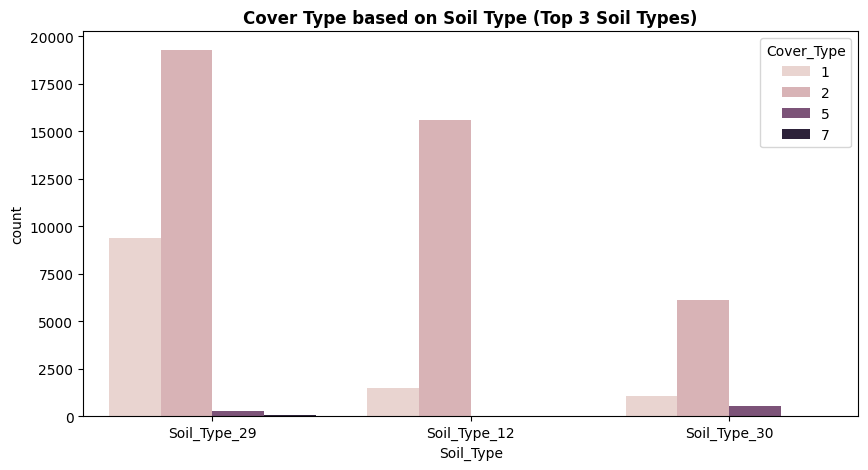

In [23]:
soil_type_cols = [f'Soil_Type_{i}' for i in range(1,41)]
temp_df['Soil_Type'] = temp_df[soil_type_cols].idxmax(axis=1)
soil_type_over_x = temp_df[temp_df['Soil_Type'].isin(temp_df['Soil_Type'].value_counts()[lambda x: x > 5000].index)]

plt.figure(figsize=(10,5))
sns.countplot(data=soil_type_over_x, x='Soil_Type', hue='Cover_Type')
plt.title('Cover Type based on Soil Type (Top 3 Soil Types)', fontweight='bold')
plt.show()

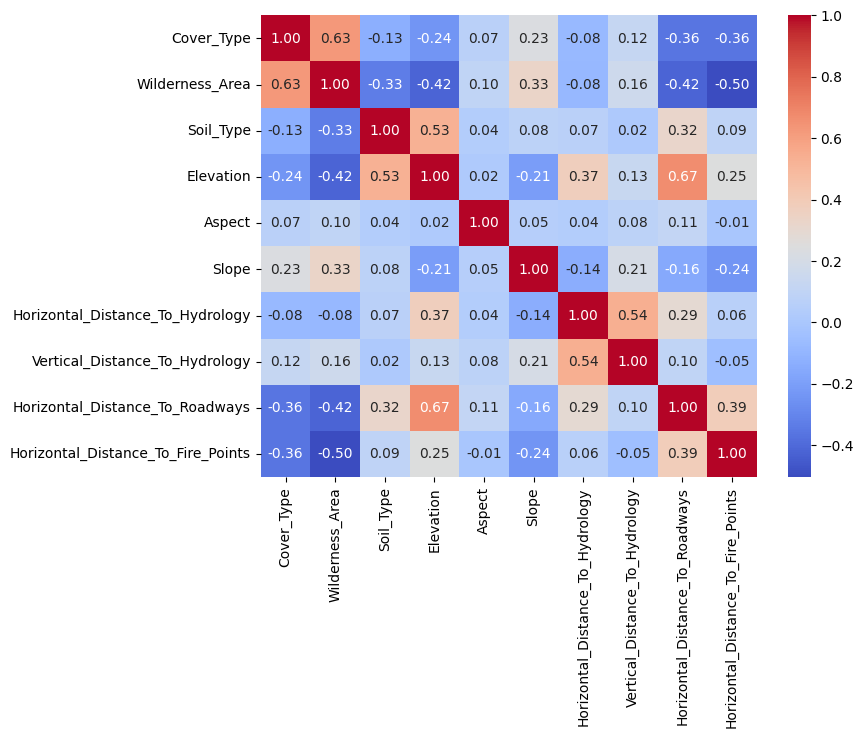

In [24]:
temp_df["Wilderness_Area"] = temp_df["Wilderness_Area"].str.extract(r"(\d+)").astype(int)
temp_df["Soil_Type"] = temp_df["Soil_Type"].str.extract(r"(\d+)").astype(int)

scatter_cols = ['Cover_Type','Wilderness_Area','Soil_Type','Elevation','Aspect','Slope','Horizontal_Distance_To_Hydrology','Vertical_Distance_To_Hydrology','Horizontal_Distance_To_Roadways','Horizontal_Distance_To_Fire_Points']
corr = temp_df[scatter_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

- We can see that Wilderness Area will be strongets predictor as its most correlated to Cover Type. So type of forest depends most based on Wilderness Area

In [25]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,1863,37,17,120,18,90,217,202,115,769,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
1,1874,18,14,0,0,90,208,209,135,793,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
2,1879,28,19,30,12,95,209,196,117,778,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
3,1888,33,22,150,46,108,209,185,103,735,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
4,1889,28,22,150,23,120,205,185,108,759,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6


In [26]:
y_train.head()

70525    1
20934    2
38501    1
24175    2
16925    2
Name: Cover_Type, dtype: int64

## 4. Baseline Model

In [27]:
#function for predictions and evaluations
def evaluate_model(name, model, X_val, y_val, X_test, y_test):
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    print(f"\n===================={name}====================\n")
    print(f"Val accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
    print(f"Test accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"Val F1-score: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
    print(f"Test F1-score: {f1_score(y_test, y_pred_test, average='macro'):.4f}")
    print(f"\nClassification Report(test):\n{classification_report(y_test, y_pred_test)}")

### Random forests

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,        #number of forests
    max_depth=None,
    min_samples_split=5,     #for overfitting
    min_samples_leaf=2,      #for overfitting
    max_features="sqrt",     #classification standard
    n_jobs=-1,               #all cores
    random_state=42,         #eproducibility
    class_weight="balanced"
)

rf.fit(X_train, y_train)
rf_y_pred = rf.predict(X_test)
evaluate_model("Random Forests", rf, X_val, y_val, X_test, y_test)


====================Random Forests====================

Val accuracy: 0.9346
Test accuracy: 0.9387
Val F1-score: 0.8759
Test F1-score: 0.8911

Classification Report(test):
              precision    recall  f1-score   support

           1       0.91      0.89      0.90      3142
           2       0.96      0.96      0.96      8896
           3       0.81      0.80      0.80       324
           4       0.88      0.97      0.93       324
           5       0.84      0.90      0.87       384
           6       0.83      0.85      0.84       324
           7       0.90      0.97      0.93       324

    accuracy                           0.94     13718
   macro avg       0.88      0.91      0.89     13718
weighted avg       0.94      0.94      0.94     13718



- Class 1 dominates — it has most samples compared to other classes. The model predicts it best because it has seen it most often.
- Class 3 is the weakest (F1 = 0.80) — due to a low number of training samples.
- No overfitting — train and test accuracy are close 
- Conclusion: 93% accuracy => Solid Baseline, but may be less reliable on rare classes

### MLP

In [29]:
#capping outliers
winsor = Winsorizer(capping_method="quantiles", tail="both", fold=0.01)
X_train_wins = winsor.fit_transform(X_train[g_cols])
X_test_wins = winsor.transform(X_test[g_cols])
X_val_wins = winsor.transform(X_val[g_cols])

#join capped back to all
remaining_cols = [col for col in X_train.columns if col not in g_cols]
X_train_full = np.hstack([X_train_wins, X_train[remaining_cols].values])
X_val_full   = np.hstack([X_val_wins,   X_val[remaining_cols].values])
X_test_full  = np.hstack([X_test_wins,  X_test[remaining_cols].values])

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled   = scaler.transform(X_val_full)
X_test_scaled  = scaler.transform(X_test_full)

#conversion to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [30]:
print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([64049, 54]) torch.Size([64049])
torch.Size([13681, 54]) torch.Size([13681])
torch.Size([13718, 54]) torch.Size([13718])


In [31]:
SEEDS = [42, 123, 256]

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

In [32]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes=7,
                 activation=nn.ReLU, dropout=0.0):
        super().__init__()
        
        layers = []
        in_dim = input_dim
        
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [33]:
def train_and_evaluate(model, X_train, y_train, X_val, y_val,
                       optimizer, criterion, epochs=100, patience=10):
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(epochs):
        #train
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        
        #validate
        model.eval()
        with torch.no_grad():
            val_out  = model(X_val)
            val_loss = criterion(val_out, y_val).item()
            val_pred = val_out.argmax(dim=1)
            val_acc  = (val_pred == y_val).float().mean().item()
        
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        #early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    model.load_state_dict(best_model_state)
    return model, history

In [34]:
def run_experiment(hidden_layers, X_train, y_train, X_val, y_val,
                   optimizer_cls, lr, criterion,
                   activation=nn.ReLU, dropout=0.0,
                   epochs=100, patience=10, seeds=SEEDS):

    input_dim = X_train.shape[1]
    all_acc, all_f1 = [], []

    for seed in seeds:
        set_seed(seed)

        model = MLP(input_dim, hidden_layers, num_classes=7,
                    activation=activation, dropout=dropout)
        optimizer = optimizer_cls(model.parameters(), lr=lr)

        model, history = train_and_evaluate(
            model, X_train, y_train, X_val, y_val,
            optimizer, criterion, epochs, patience
        )

        #metrics
        model.eval()
        with torch.no_grad():
            preds = model(X_val).argmax(dim=1).numpy()
            true  = y_val.numpy()

        acc = accuracy_score(true, preds)
        f1  = f1_score(true, preds, average='macro')
        all_acc.append(acc)
        all_f1.append(f1)

    mean_acc = np.mean(all_acc)
    std_acc  = np.std(all_acc)
    mean_f1  = np.mean(all_f1)
    std_f1   = np.std(all_f1)

    print(f"  Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"  F1 macro: {mean_f1:.4f} ± {std_f1:.4f}  (main metric)")

    return {"mean_f1": mean_f1, "std_f1": std_f1,
            "mean_acc": mean_acc, "std_acc": std_acc}

In [35]:
INPUT_DIM    = X_train_tensor.shape[1]
FIXED_LR     = 0.001
FIXED_OPT    = torch.optim.Adam
CRITERION    = nn.CrossEntropyLoss()

# y_train_tensor labels must 0-indexed
y_train_t = y_train_tensor - 1
y_val_t   = y_val_tensor - 1
y_test_t  = y_test_tensor - 1

### Experiment 1 - topologies

In [36]:
topologies = {
    "tiny":       [32],
    "small":      [64, 32],
    "medium":     [256, 128, 64],
    "large":      [512, 256, 128, 64],
    "very_large": [1024, 512, 256, 128, 64],
}

topology_results = {}
for name, layers in topologies.items():
    print(f"\n=== Topology: {name} {layers} ===")
    res = run_experiment(
        layers, X_train_tensor, y_train_t, X_val_tensor, y_val_t,
        optimizer_cls=FIXED_OPT, lr=FIXED_LR, criterion=CRITERION
    )
    topology_results[name] = res

best_topology_name   = max(topology_results, key=lambda k: topology_results[k]["mean_f1"])
best_topology_layers = topologies[best_topology_name]
print(f"\nBest Topology: {best_topology_name} {best_topology_layers}")


=== Topology: tiny [32] ===
  Accuracy: 0.7446 ± 0.0089
  F1 macro: 0.5414 ± 0.0266  (main metric)

=== Topology: small [64, 32] ===
  Accuracy: 0.7721 ± 0.0034
  F1 macro: 0.5840 ± 0.0173  (main metric)

=== Topology: medium [256, 128, 64] ===
  Accuracy: 0.8241 ± 0.0011
  F1 macro: 0.6917 ± 0.0015  (main metric)

=== Topology: large [512, 256, 128, 64] ===
  Accuracy: 0.8357 ± 0.0013
  F1 macro: 0.7193 ± 0.0072  (main metric)

=== Topology: very_large [1024, 512, 256, 128, 64] ===
  Accuracy: 0.8407 ± 0.0002
  F1 macro: 0.7374 ± 0.0070  (main metric)

Best Topology: very_large [1024, 512, 256, 128, 64]


### Experiment 2 - optimizers

In [37]:
optimizers = {
    "SGD":      torch.optim.SGD,
    "Adam":     torch.optim.Adam,
    "RMSprop":  torch.optim.RMSprop,
}

optimizer_results = {}
for name, opt_cls in optimizers.items():
    print(f"\n=== Optimizer: {name} ===")
    res = run_experiment(
        best_topology_layers, X_train_tensor, y_train_t, X_val_tensor, y_val_t,
        optimizer_cls=opt_cls, lr=FIXED_LR, criterion=CRITERION
    )
    optimizer_results[name] = res

best_optimizer_name = max(optimizer_results, key=lambda k: optimizer_results[k]["mean_f1"])
best_optimizer      = optimizers[best_optimizer_name]
print(f"\nBest Optimizer: {best_optimizer_name}")


=== Optimizer: SGD ===
  Accuracy: 0.1330 ± 0.0908
  F1 macro: 0.0561 ± 0.0423  (main metric)

=== Optimizer: Adam ===
  Accuracy: 0.8407 ± 0.0002
  F1 macro: 0.7374 ± 0.0070  (main metric)

=== Optimizer: RMSprop ===
Early stopping at epoch 91
Early stopping at epoch 94
Early stopping at epoch 96
  Accuracy: 0.8143 ± 0.0109
  F1 macro: 0.6400 ± 0.0268  (main metric)

Best Optimizer: Adam


### Experiment 3 - learning rate

In [38]:
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]

lr_results = {}
for lr in learning_rates:
    print(f"\n=== Learning rate: {lr} ===")
    res = run_experiment(
        best_topology_layers, X_train_tensor, y_train_t, X_val_tensor, y_val_t,
        optimizer_cls=best_optimizer, lr=lr, criterion=CRITERION
    )
    lr_results[lr] = res

best_lr = max(lr_results, key=lambda k: lr_results[k]["mean_f1"])
print(f"\nBest LR: {best_lr}")


=== Learning rate: 0.1 ===
Early stopping at epoch 20
Early stopping at epoch 36
Early stopping at epoch 62
  Accuracy: 0.6486 ± 0.0000
  F1 macro: 0.1124 ± 0.0000  (main metric)

=== Learning rate: 0.01 ===
  Accuracy: 0.8523 ± 0.0023
  F1 macro: 0.7638 ± 0.0201  (main metric)

=== Learning rate: 0.001 ===
  Accuracy: 0.8407 ± 0.0002
  F1 macro: 0.7374 ± 0.0070  (main metric)

=== Learning rate: 0.0001 ===
  Accuracy: 0.7486 ± 0.0042
  F1 macro: 0.4262 ± 0.0518  (main metric)

=== Learning rate: 1e-05 ===
  Accuracy: 0.2740 ± 0.2088
  F1 macro: 0.0956 ± 0.0262  (main metric)

Best LR: 0.01


### Experiment 4 - activation functions

In [39]:
activations = {
    "ReLU":      nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "ELU":       nn.ELU,
    "Tanh":      nn.Tanh,
    "GELU":      nn.GELU,
}

activation_results = {}
for name, act in activations.items():
    print(f"\n=== Activation: {name} ===")
    res = run_experiment(
        best_topology_layers, X_train_tensor, y_train_t, X_val_tensor, y_val_t,
        optimizer_cls=best_optimizer, lr=best_lr,
        criterion=CRITERION, activation=act
    )
    activation_results[name] = res

best_activation_name = max(activation_results, key=lambda k: activation_results[k]["mean_f1"])
best_activation      = activations[best_activation_name]
print(f"\nBest Activation: {best_activation_name}")


=== Activation: ReLU ===
  Accuracy: 0.8523 ± 0.0023
  F1 macro: 0.7638 ± 0.0201  (main metric)

=== Activation: LeakyReLU ===
Early stopping at epoch 97
  Accuracy: 0.8548 ± 0.0061
  F1 macro: 0.7841 ± 0.0096  (main metric)

=== Activation: ELU ===
Early stopping at epoch 81
  Accuracy: 0.8451 ± 0.0099
  F1 macro: 0.7512 ± 0.0200  (main metric)

=== Activation: Tanh ===
Early stopping at epoch 59
Early stopping at epoch 90
Early stopping at epoch 73
  Accuracy: 0.8234 ± 0.0127
  F1 macro: 0.6635 ± 0.0104  (main metric)

=== Activation: GELU ===
Early stopping at epoch 99
Early stopping at epoch 64
Early stopping at epoch 75
  Accuracy: 0.8722 ± 0.0121
  F1 macro: 0.7867 ± 0.0150  (main metric)

Best Activation: GELU


### Experiment 5 - regularizations

In [40]:
regularization_configs = {
    "none":            {"dropout": 0.0, "weight_decay": 0.0},
    "dropout_02":      {"dropout": 0.2, "weight_decay": 0.0},
    "dropout_04":      {"dropout": 0.4, "weight_decay": 0.0},
    "l2":              {"dropout": 0.0, "weight_decay": 1e-4},
    "dropout_l2":      {"dropout": 0.2, "weight_decay": 1e-4},
}

reg_results = {}
for name, cfg in regularization_configs.items():
    print(f"\n=== Regularization: {name} ===")
    res = run_experiment(
        best_topology_layers, X_train_tensor, y_train_t, X_val_tensor, y_val_t,
        optimizer_cls=best_optimizer, lr=best_lr,
        criterion=CRITERION, activation=best_activation,
        dropout=cfg["dropout"]
    )
    reg_results[name] = res


=== Regularization: none ===
Early stopping at epoch 99
Early stopping at epoch 64
Early stopping at epoch 75
  Accuracy: 0.8722 ± 0.0121
  F1 macro: 0.7867 ± 0.0150  (main metric)

=== Regularization: dropout_02 ===
  Accuracy: 0.9108 ± 0.0028
  F1 macro: 0.8260 ± 0.0082  (main metric)

=== Regularization: dropout_04 ===
  Accuracy: 0.8970 ± 0.0024
  F1 macro: 0.8065 ± 0.0020  (main metric)

=== Regularization: l2 ===
Early stopping at epoch 99
Early stopping at epoch 64
Early stopping at epoch 75
  Accuracy: 0.8722 ± 0.0121
  F1 macro: 0.7867 ± 0.0150  (main metric)

=== Regularization: dropout_l2 ===
  Accuracy: 0.9108 ± 0.0028
  F1 macro: 0.8260 ± 0.0082  (main metric)


Test Accuracy: 0.9103
Test F1 macro: 0.8096


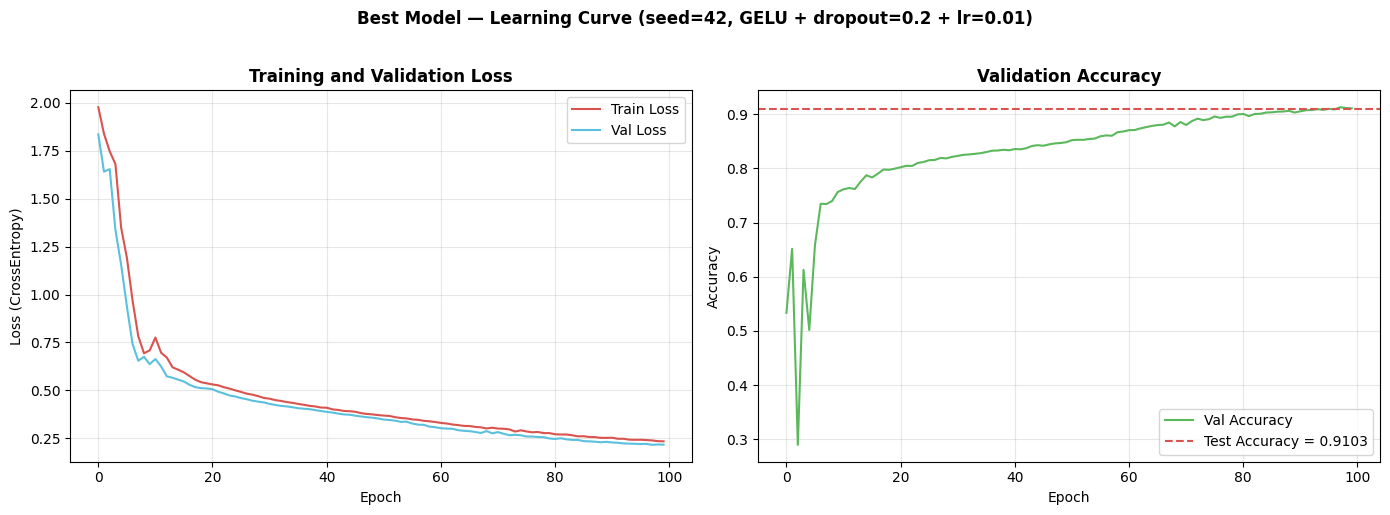

In [44]:
set_seed(42)

best_model = MLP(
    input_dim=INPUT_DIM,
    hidden_layers=[1024, 512, 256, 128, 64],
    num_classes=7,
    activation=nn.GELU,
    dropout=0.2
)

optimizer = torch.optim.Adam(best_model.parameters(), lr=0.01)

best_model, history = train_and_evaluate(
    best_model,
    X_train_tensor, y_train_t,
    X_val_tensor, y_val_t,
    optimizer, CRITERION,
    epochs=100, patience=10
)

# Test evaluation
best_model.eval()
with torch.no_grad():
    test_preds = best_model(X_test_tensor).argmax(dim=1).numpy()
    test_true  = y_test_t.numpy()

test_acc = accuracy_score(test_true, test_preds)
test_f1  = f1_score(test_true, test_preds, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 macro: {test_f1:.4f}")

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", color="#d9534f", linewidth=1.5)
axes[0].plot(history["val_loss"],   label="Val Loss",   color="#5bc0de", linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (CrossEntropy)")
axes[0].set_title("Training and Validation Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_acc"], label="Val Accuracy", color="#5cb85c", linewidth=1.5)
axes[1].axhline(test_acc, color="#d9534f", linestyle="--", 
                linewidth=1.5, label=f"Test Accuracy = {test_acc:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Best Model — Learning Curve (seed=42, GELU + dropout=0.2 + lr=0.01)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('x', dpi=300, bbox_inches='tight')
plt.show()